# Find Contours in Video
This notebook uses the `find_contours.py` script to analyze video files and save contour results to a text file.

### First step is to manually identify where the tanks are in the video

This will be used later to identify the tanks as experimental replicates 

In [2]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos

Figure(640x480)


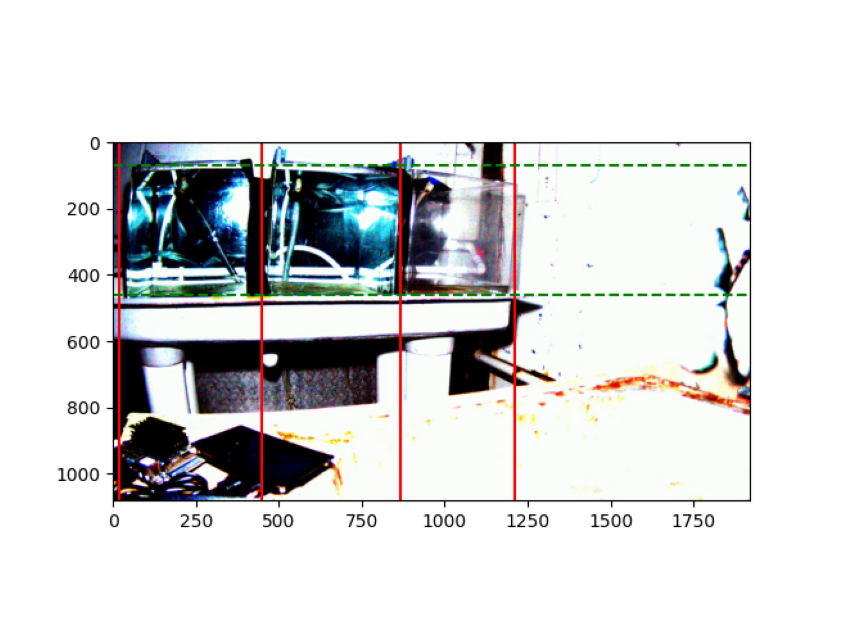

In [30]:
import subprocess
import matplotlib.pyplot as plt
import cv2
import os

# Parameters
video_path = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part1.mp4'
frame_number = 500
x_lines = [20, 450, 865, 1210]
y_lines = [70, 460]
output_image = '../../results/041025PA_experimental.png'  # Save to results folder

# Build command
cmd = [
    'python3', '../../scripts/visualize_tanx.py',
    '-v', video_path,
    '-f', str(frame_number),
    '-t', *map(str, x_lines),
    '-y', *map(str, y_lines),
    '-o', output_image
]

# Run the script
subprocess.run(cmd, check=True)

# Display the image in the notebook
if os.path.exists(output_image):
    img = cv2.imread(output_image)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()
else:
    print('Visualization image not found.')

### Next, plot overall brightness over time to inform threshold

In [37]:
import subprocess
import os

video_dir = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental'
output_dir = '../../results'
video_prefix = '041025PA_experimental_part'
video_numbers = [4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27]

#video_numbers = [3]

for num in video_numbers:
    video_file = os.path.join(video_dir, f'{video_prefix}{num}.mp4')
    output_csv = os.path.join(output_dir, f'brightness_over_time_{video_prefix}{num}.csv')
    cmd = [
    'python3', '../../scripts/brightnessOverTimeMB.py',
    '-f', video_file,
    '-b', '0',
    '-w', '255',
    '-t', *map(str, x_lines),
    '-i', '1',
    '-s', '1',
    '-v', '0',
    '--ylim', '75', '470',
    '--xlim', '20', '1210',
    '-o', output_csv
    ]
    print(f'Processing {video_file}...')
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in process.stdout:
        print(line, end='', flush=True)
    process.wait()
    print(f'Finished {video_file}\n')

Processing /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part4.mp4...
Starting brightness analysis for: /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part4.mp4
Opened video: /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part4.mp4, success: True
Total frames reported by OpenCV: 27001
FPS reported by OpenCV: 10.0
Duration (seconds): 2700.10
Duration (minutes): 45.00
Progress: frame 1000, video_time 01:40
Progress: frame 2000, video_time 03:20
Progress: frame 3000, video_time 05:00
Progress: frame 4000, video_time 06:40
Progress: frame 5000, video_time 08:20
Progress: frame 6000, video_time 10:00
Progress: frame 7000, video_time 11:40
Progress: frame 8000, video_time 13:20
Progress: frame 9000, video_time 15:00
Progress: frame 10000, video_time 16:40
Progress: frame 11000, video_time 18:20
Progress: frame 12000, video_time 20:00


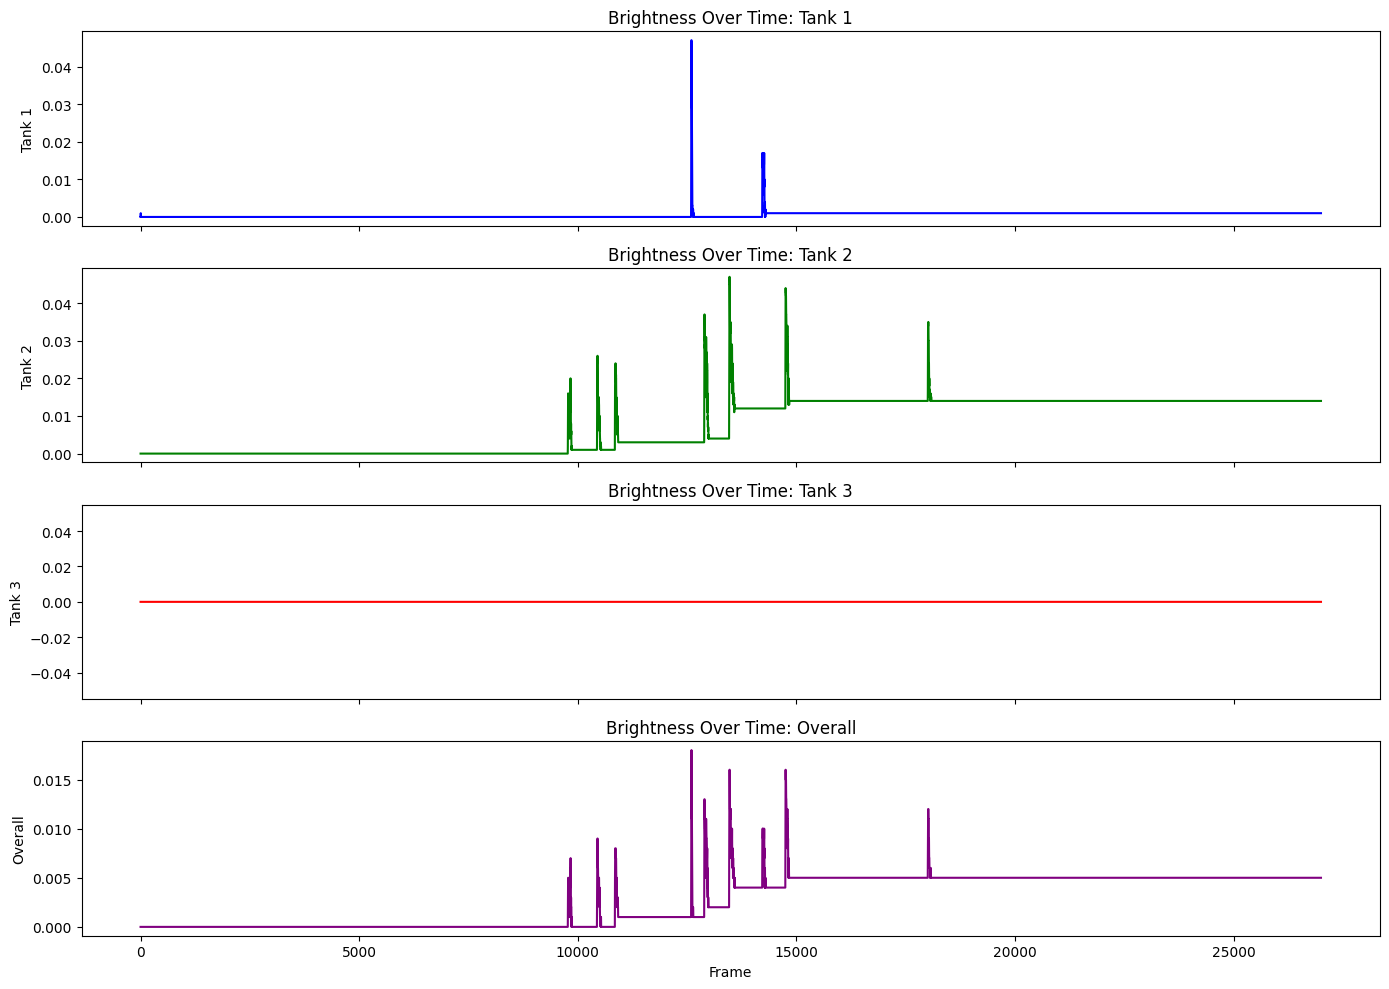

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = '../../results/brightness_over_time_041025PA_experimental_part3.csv'
df = pd.read_csv(csv_path, header=0)

x = df['frame']
tank1 = df['tank1']
tank2 = df['tank2']
tank3 = df['tank3']
overall = df['overall']

fig, axs = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axs[0].plot(x, tank1, color='blue')
axs[0].set_ylabel('Tank 1')
axs[0].set_title('Brightness Over Time: Tank 1')

axs[1].plot(x, tank2, color='green')
axs[1].set_ylabel('Tank 2')
axs[1].set_title('Brightness Over Time: Tank 2')

axs[2].plot(x, tank3, color='red')
axs[2].set_ylabel('Tank 3')
axs[2].set_title('Brightness Over Time: Tank 3')

axs[3].plot(x, overall, color='purple')
axs[3].set_ylabel('Overall')
axs[3].set_title('Brightness Over Time: Overall')
axs[3].set_xlabel('Frame')

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
import os

files = [
    'brightness_over_time_041025PA_experimental_part3.csv',
    'brightness_over_time_041025PA_experimental_part4.csv',
    'brightness_over_time_041025PA_experimental_part5.csv',
    'brightness_over_time_041025PA_experimental_part6.csv',
    'brightness_over_time_041025PA_experimental_part7.csv',
    'brightness_over_time_041025PA_experimental_part8.csv',
    'brightness_over_time_041025PA_experimental_part9.csv',
    'brightness_over_time_041025PA_experimental_part10.csv',
    'brightness_over_time_041025PA_experimental_part11.csv',
    'brightness_over_time_041025PA_experimental_part12.csv',
    'brightness_over_time_041025PA_experimental_part13.csv',
    'brightness_over_time_041025PA_experimental_part14.csv',
    'brightness_over_time_041025PA_experimental_part15.csv',
    'brightness_over_time_041025PA_experimental_part16.csv',
    'brightness_over_time_041025PA_experimental_part17.csv',
    'brightness_over_time_041025PA_experimental_part18.csv',
    'brightness_over_time_041025PA_experimental_part19.csv',
    'brightness_over_time_041025PA_experimental_part20.csv',
    'brightness_over_time_041025PA_experimental_part21.csv',
    'brightness_over_time_041025PA_experimental_part22.csv',
    'brightness_over_time_041025PA_experimental_part23.csv',
    'brightness_over_time_041025PA_experimental_part24.csv',
    'brightness_over_time_041025PA_experimental_part25.csv',
    'brightness_over_time_041025PA_experimental_part26.csv'
]

input_dir = '/home/local/ADS/oakley/labdata/users/Oakley/GitHub/lunar/results'
dfs = []

for i, fname in enumerate(files):
    fpath = os.path.join(input_dir, fname)
    if os.path.getsize(fpath) == 0:
        print(f"Empty file: {fname}")
        continue
    if i == 0:
        df = pd.read_csv(fpath, header=0)
    else:
        df = pd.read_csv(fpath, header=0, skiprows=1)
    df['source_file'] = fname
    dfs.append(df)

concat_df = pd.concat(dfs, ignore_index=True)

# Only keep expected columns
expected_cols = ['frame', 'tank1', 'tank2', 'tank3', 'overall', 'source_file']
concat_df = concat_df[expected_cols]

# Drop rows where all but source_file are NaN or empty
concat_df = concat_df.dropna(subset=['frame', 'tank1', 'tank2', 'tank3', 'overall'], how='all')

concat_df.to_csv(os.path.join(input_dir, 'concatenated_brightness.csv'), index=False, header=True)

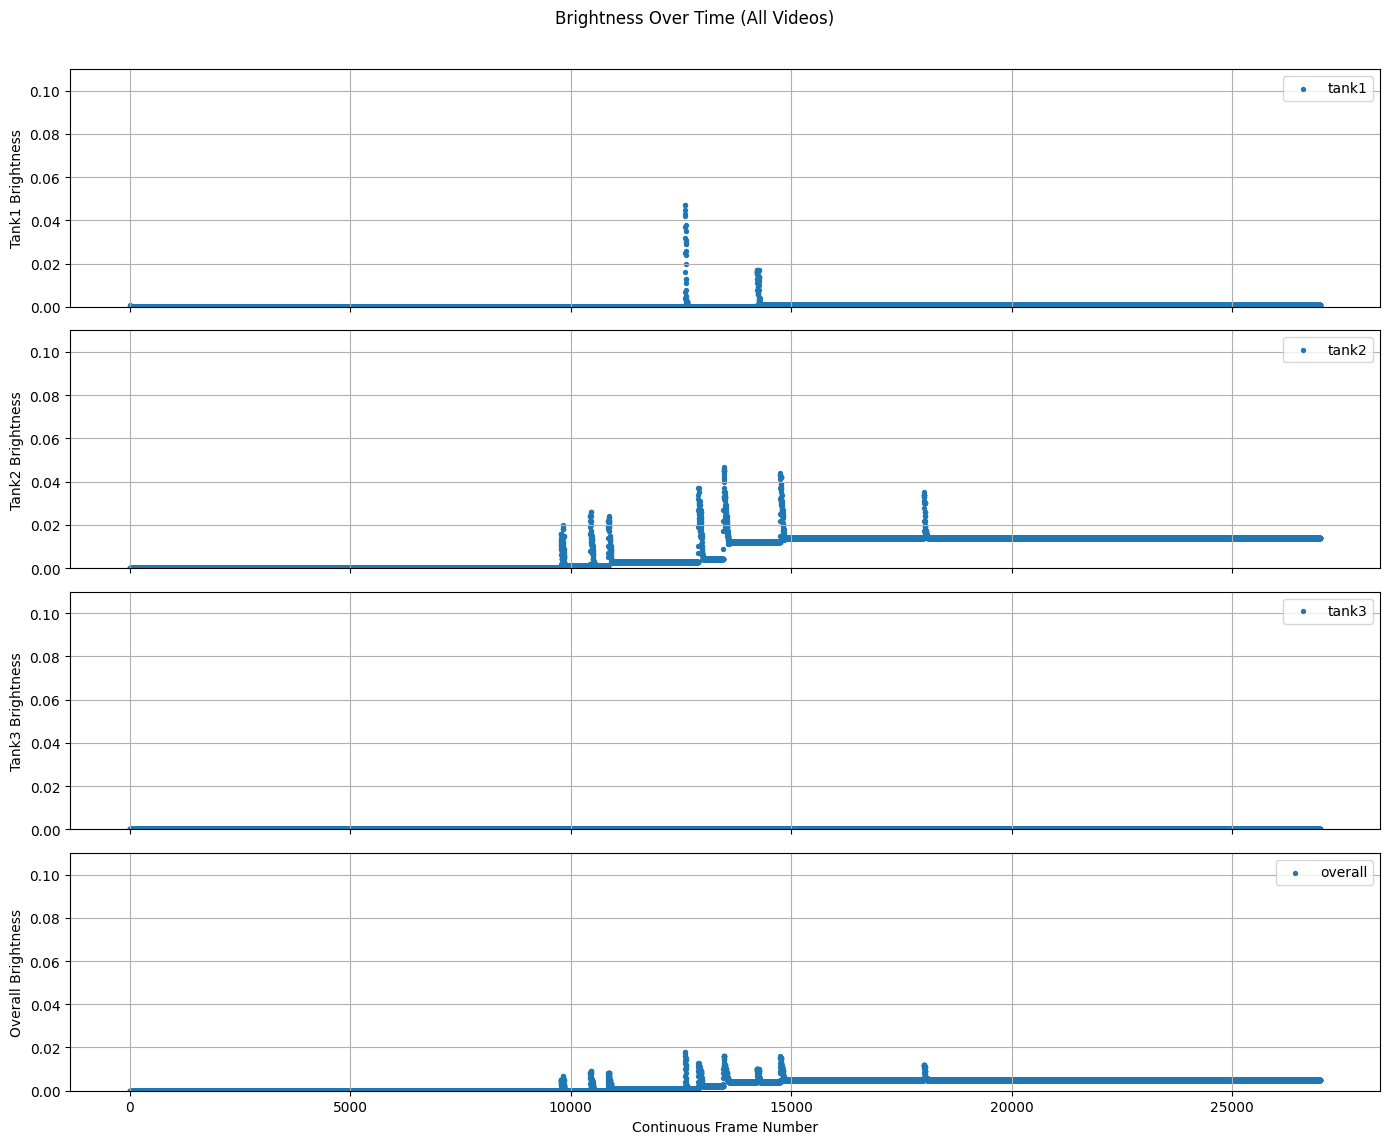

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load CSV results (assumes one header row)
csv_path = '../../results/concatenated_brightness.csv'
df = pd.read_csv(csv_path)

# Renumber frames to be continuous
frame_col = 'frame'
source_file_col = 'source_file' if 'source_file' in df.columns else df.columns[-1]
new_frame_numbers = []
current_frame = 0
last_file = None

for idx, row in df.iterrows():
    file = row[source_file_col]
    if file != last_file:
        current_frame = 0
        last_file = file
    current_frame += 1
    new_frame_numbers.append(current_frame if idx == 0 else new_frame_numbers[-1] + 1 if file == last_file else 1)


# Assign a global continuous frame number
df['continuous_frame'] = range(1, len(df) + 1)# Cap brightness values above 0.1 at 0.1 for plotting
def cap_brightness(series, cap=0.1):
    return series.apply(lambda val: cap if val > cap else val)

# Plot 4 stacked plots: tank1, tank2, tank3, overall
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
tank_cols = ['tank1', 'tank2', 'tank3', 'overall']

for i, col in enumerate(tank_cols):
    y = cap_brightness(df[col])
    axes[i].scatter(df['continuous_frame'], y, s=8)
    axes[i].set_ylabel(f'{col.capitalize()} Brightness')
    axes[i].set_ylim(0, 0.11)
    axes[i].grid(True)
    axes[i].legend([col])

axes[-1].set_xlabel('Continuous Frame Number')
plt.suptitle('Brightness Over Time (All Videos)')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

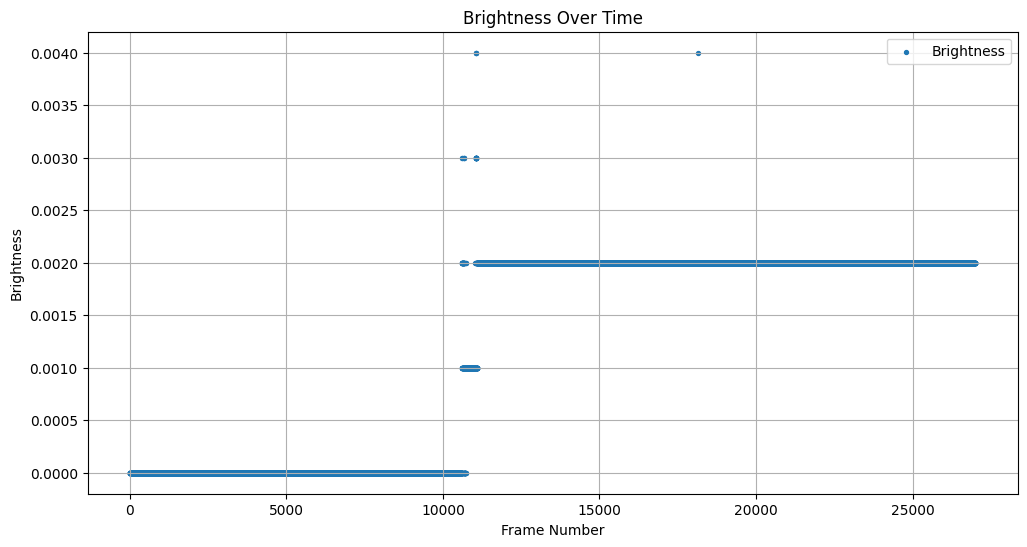

In [19]:
#Plot brightness over time

import pandas as pd
import matplotlib.pyplot as plt

# Load CSV results
csv_path = '/home/local/ADS/oakley/labdata/users/Oakley/GitHub/lunar/results/brightness_over_time_041025PA_part4_experimental.csv'
df = pd.read_csv(csv_path, header=None)

# Plot frame (col 0) vs brightness (col 2) as points
plt.figure(figsize=(12, 6))
plt.scatter(df[0], df[2], label='Brightness', s=8)
plt.xlabel('Frame Number')
plt.ylabel('Brightness')
plt.title('Brightness Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [1]:
# Import required functions from the script
import sys
sys.path.append('../../scripts')  # Adjust path if needed
from find_contours import find_contours_from_videos


# Set parameters for contour finding
video_pattern = '/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part??_CFR10.mp4'
output_file = '041025PA_control.tab'
black = 110
minArea = 1.5
maxArea = 1000.0
brightnessThreshold = 200
threads = 4
maxy = None

# Run contour finding and write results to file
xlim = [20, 1210]
ylim = [70, 460]

results = find_contours_from_videos(
    video_pattern=video_pattern,
    black=black,
    minArea=minArea,
    maxArea=maxArea,
    brightnessThreshold=brightnessThreshold,
    threads=threads,
    outfile=output_file,
    maxy=maxy,
    xlim=xlim,
    ylim=ylim
)
print(f'Contour results written to {output_file}')

Processing videos:   0%|          | 0/24 [00:00<?, ?it/s]

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part03_CFR10.mp4
Process

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part04_CFR10.mp4
Process

...

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part24_CFR10.mp4
Process

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part25_CFR10.mp4
Process

/home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR…

Processed 500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 1000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 1500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 2000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 2500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 3000 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Processed 3500 frames in /home/local/ADS/oakley/labdata/users/McKinley/Panama2025/10Apr25/Experimental/041025PA_experimental_part26_CFR10.mp4
Process

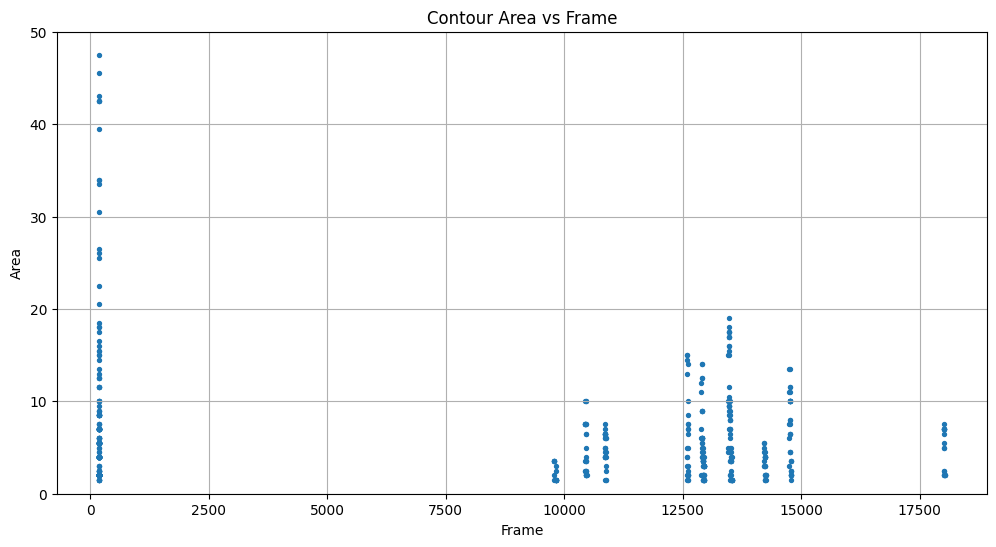

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the tab-separated file
df = pd.read_csv('contours_contours_041025PA_control.tab', sep='\t')

# Plot frame vs area
plt.figure(figsize=(12, 6))
plt.scatter(df['frame'], df['area'], s=8)
plt.xlabel('Frame')
plt.ylabel('Area')
plt.title('Contour Area vs Frame')
plt.grid(True)
plt.ylim(0, 50)
plt.show()